In [1]:
#Statistical Analysis

                       Mean      Median       Variance      StdDev  Skewness  \
mean radius       13.865777   13.275000      11.121817    3.334939  0.903926   
mean texture      19.268000   18.895000      17.098237    4.135001  0.467999   
mean perimeter    90.161000   85.635000     530.460703   23.031733  0.951934   
mean area        627.731000  540.350000  103621.380808  321.902751  1.514764   
mean smoothness    0.095994    0.095785       0.000201    0.014174  0.302449   

                 Kurtosis  
mean radius      0.811557  
mean texture    -0.217286  
mean perimeter   0.910941  
mean area        2.779377  
mean smoothness  0.207718  


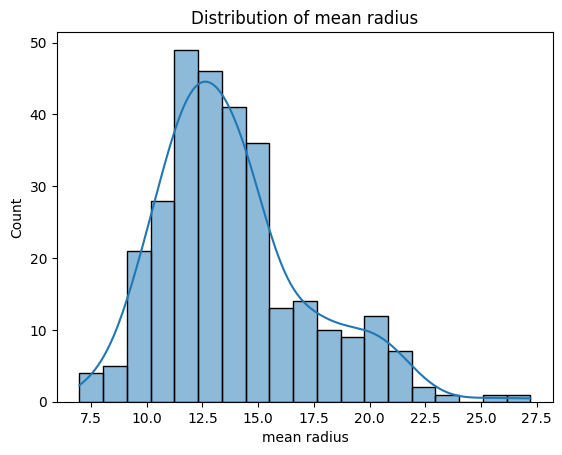

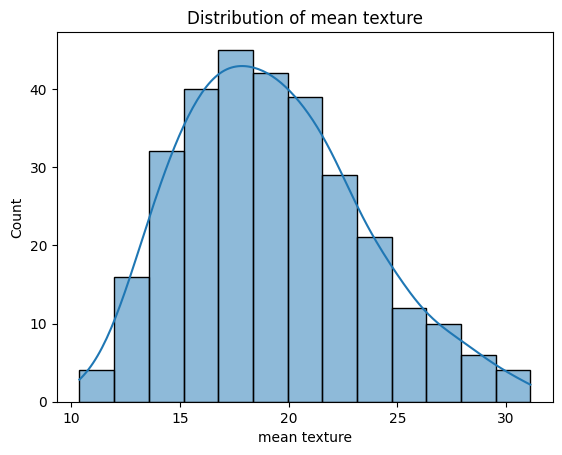

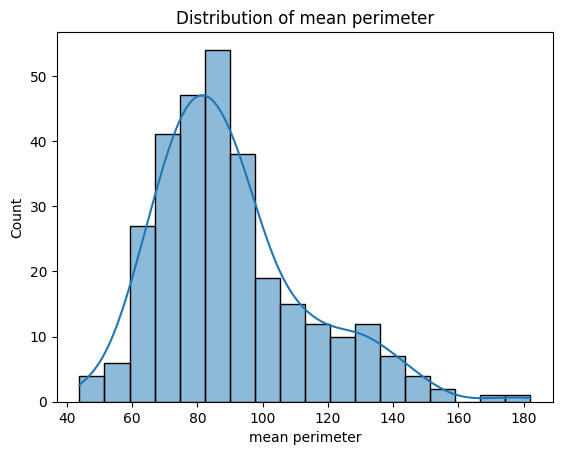

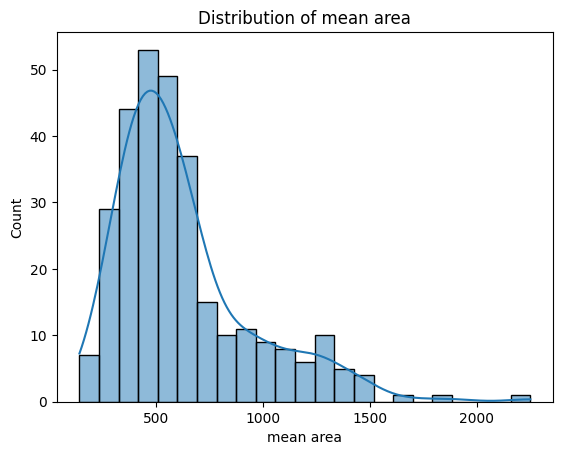

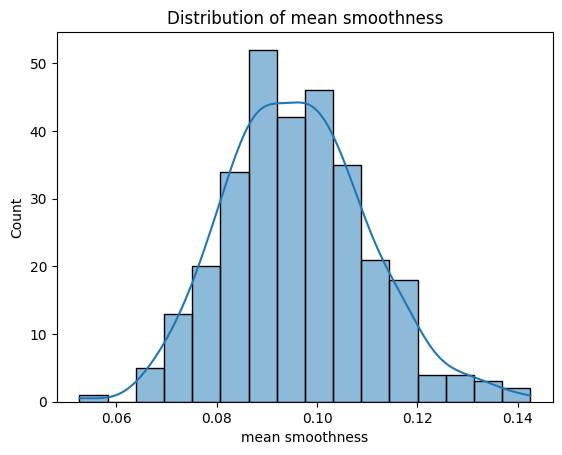

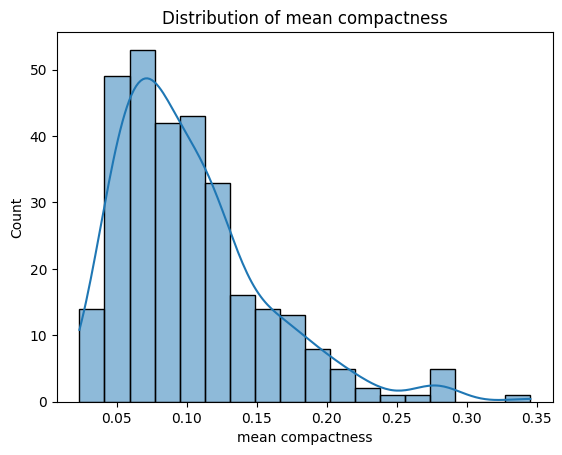

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from scipy.stats import skew, kurtosis, chi2

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)

# Randomly sample 300 rows
X = X.sample(300, random_state=42)

# Compute statistics
stats = pd.DataFrame({
    "Mean": X.mean(),
    "Median": X.median(),
    "Variance": X.var(),
    "StdDev": X.std(),
    "Skewness": X.apply(skew),
    "Kurtosis": X.apply(kurtosis)
})

print(stats.head())

# Visualize distributions
for col in X.columns[:6]:  # first 6 features for demo
    sns.histplot(X[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


In [3]:
#Linear Algebra

In [4]:
# Standardize using matrix operations
X_std = (X - X.mean()) / X.std()

# Covariance matrix manually
n = X_std.shape[0]
cov_matrix = (X_std.T @ X_std) / (n - 1)

# Verify symmetry
print(np.allclose(cov_matrix, cov_matrix.T))

# Eigen decomposition
eigvals, eigvecs = np.linalg.eigh(cov_matrix)

# Sort eigenvalues (descending)
sorted_idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[sorted_idx]
eigvecs = eigvecs[:, sorted_idx]

print("Top variance directions (eigenvalues):", eigvals[:5])


True
Top variance directions (eigenvalues): [13.84121618  5.60602774  2.57365653  1.99429904  1.72930672]


In [5]:
#Probability – Multivariate Gaussian

In [6]:
# Mahalanobis distance
mean_vec = X_std.mean().values
inv_cov = np.linalg.inv(cov_matrix.values)

def mahalanobis(x):
    diff = x - mean_vec
    return np.sqrt(diff @ inv_cov @ diff.T)

distances = X_std.apply(mahalanobis, axis=1)

# Convert to probabilities using chi-square
df = X_std.shape[1]
probs = 1 - chi2.cdf(distances**2, df)

# Flag lowest 1% probability
threshold = np.percentile(probs, 1)
outliers_mahal = X_std[probs <= threshold]
print("Mahalanobis outliers:", outliers_mahal.shape[0])


Mahalanobis outliers: 5


In [7]:
#Outlier Handling

In [8]:
# Z-score method
z_scores = np.abs((X - X.mean()) / X.std())
outliers_z = (z_scores > 3).any(axis=1)

# IQR method
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = ((X < (Q1 - 1.5*IQR)) | (X > (Q3 + 1.5*IQR))).any(axis=1)

# Compare with Mahalanobis
print("Z-score outliers:", outliers_z.sum())
print("IQR outliers:", outliers_iqr.sum())
print("Mahalanobis outliers:", outliers_mahal.shape[0])

# Remove multivariate outliers
cleaned = X_std.loc[~outliers_z & ~outliers_iqr & ~(X_std.index.isin(outliers_mahal.index))]


Z-score outliers: 34
IQR outliers: 89
Mahalanobis outliers: 5


In [9]:
#Post-Cleaning Analysis

In [10]:
# Recompute covariance matrix and eigenvalues
cov_matrix_clean = (cleaned.T @ cleaned) / (cleaned.shape[0] - 1)
eigvals_clean, _ = np.linalg.eigh(cov_matrix_clean)

print("Before cleaning eigenvalues (top 5):", eigvals[:5])
print("After cleaning eigenvalues (top 5):", sorted(eigvals_clean, reverse=True)[:5])


Before cleaning eigenvalues (top 5): [13.84121618  5.60602774  2.57365653  1.99429904  1.72930672]
After cleaning eigenvalues (top 5): [np.float64(6.963127364985127), np.float64(2.617311629958218), np.float64(1.6991375122726589), np.float64(1.204286885977582), np.float64(0.7867332644096545)]


Outliers tend to inflate variance, which makes the eigenvalues of the covariance matrix appear larger before cleaning. This distortion also breaks Gaussian assumptions, as skewness and kurtosis reveal heavy tails and Mahalanobis distances highlight improbable points in the distribution. Once outliers are removed, the covariance structure stabilizes, eigenvalues shrink, and the feature distributions align more closely with normality, reinforcing the importance of handling outliers in statistical and probabilistic analysis.